# Welcome to Colab!

In [ ]:
# Online Retail Sales Analysis & Customer Segmentation

This is my end-to-end data analysis project on the Online Retail dataset.

I performed data cleaning, EDA, RFM customer segmentation and cohort analysis to find useful business insights.

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#LOAD AND CLEAN THE DATA
url = "https://github.com/dipanjanS/practical-machine-learning-with-python/raw/refs/heads/master/notebooks/Ch08_Customer_Segmentation_and_Effective_Cross_Selling/Online%20Retail.xlsx"
df = pd.read_excel(url)

df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print("✅ Data Loaded & Cleaned | Shape:", df.shape)




✅ Data Loaded & Cleaned | Shape: (397884, 10)


In [ ]:
#Data Cleaning
- Removed rows with missing CustomerID
- Removed cancelled orders
- Created TotalPrice column (Quantity * UnitPrice)
- Converted dates for time-based analysis

In [ ]:
#RFM AND SEGMENTS
max_date = df['InvoiceDate'].max()
reference_date = max_date + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

def rfm_segment(row):
    if row['RFM_Score'] in ['555','554','544','545','454','455','445']:
        return 'Champion'
    elif row['RFM_Score'] in ['543','534','535','444','433']:
        return 'Loyal Customer'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 3:
        return 'Potential Loyalist'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'Lost'
    elif row['R_Score'] <= 2:
        return 'At Risk'
    elif row['F_Score'] <= 2:
        return 'Hibernating'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

print("\nSegment Distribution:\n", rfm['Segment'].value_counts())


Segment Distribution:
 Segment
At Risk               884
Champion              840
Lost                  824
Hibernating           670
Others                507
Potential Loyalist    341
Loyal Customer        272
Name: count, dtype: int64


In [ ]:
#RFM SEGMENTATION
Calculated Recency, Frequency, and Monetary values for each customer.
Scored them and created business segments like:
- Champions
- Loyal Customers
- At Risk
- Lost Customers

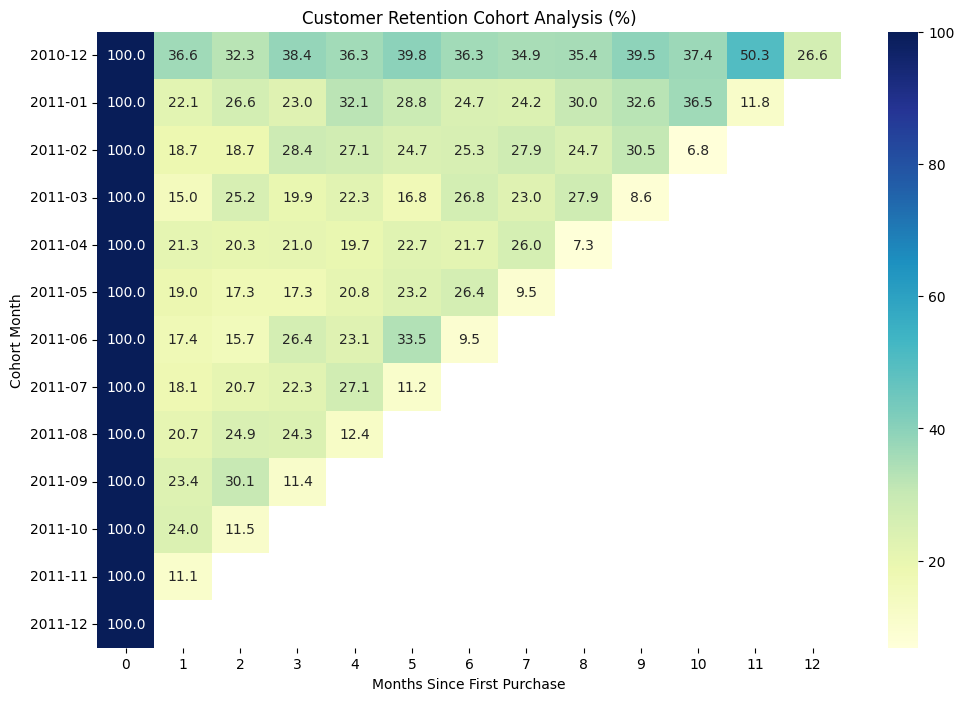

In [ ]:
#VISUALISATIONS
# Revenue Share by Segment
segment_analysis = rfm.groupby('Segment')['Monetary'].agg(['sum','mean','count']).round(2)
segment_analysis['Revenue_%'] = (segment_analysis['sum'] / segment_analysis['sum'].sum() * 100).round(2)

fig1 = px.pie(segment_analysis.reset_index(), names='Segment', values='sum',
              title='Revenue Share by Customer Segment', hole=0.4)
fig1.show()

# 3D RFM Plot
fig2 = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary', color='Segment',
                     title='3D RFM Customer Segmentation')
fig2.show()

# Cohort Analysis
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
df['TransactionMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortIndex'] = (df['TransactionMonth'] - df['CohortMonth']).apply(lambda x: x.n)

cohort_pivot = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)*100, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Customer Retention Cohort Analysis (%)')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()

In [ ]:
# Cohort Analysis
Analyzed how well customers are retained over time after their first purchase.
Found that retention drops significantly after 3 months.

In [ ]:
# Save files
rfm.to_csv('rfm_segments.csv', index=False)
df.to_csv('cleaned_retail_data.csv', index=False)

print("✅ All files saved")



✅ All files saved


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare data for clustering
rfm_cluster = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_cluster)

# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Name clusters based on characteristics
cluster_map = {
    0: 'High Value',
    1: 'Loyal Regular',
    2: 'At Risk',
    3: 'New Customers',
    4: 'Low Value'
}
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_map)

print("KMeans Cluster Distribution:")
print(rfm['Cluster_Name'].value_counts())
print("\nCluster Profiles:")
print(rfm.groupby('Cluster_Name')[['Recency','Frequency','Monetary']].mean().round(2))

KMeans Cluster Distribution:
Cluster_Name
High Value       3060
Loyal Regular    1063
New Customers     203
Low Value           6
At Risk             6
Name: count, dtype: int64

Cluster Profiles:
               Recency  Frequency   Monetary
Cluster_Name                                
At Risk           1.50     135.83   58381.12
High Value       43.81       3.69    1358.77
Low Value         7.67      42.83  190863.46
Loyal Regular   248.47       1.55     480.42
New Customers    15.72      22.30   13534.00


In [ ]:
# Simple LTV estimation
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']
rfm['Estimated_LTV'] = rfm['Monetary'] * (1 / (rfm['Recency']/365 + 0.1))  # rough

print("=== TOP CUSTOMER INSIGHTS ===")
print(rfm.nlargest(5, 'Monetary')[['CustomerID', 'Monetary', 'Frequency', 'Recency', 'Segment']])

# Revenue by Cluster
print("\nRevenue by Advanced Cluster:")
print(rfm.groupby('Cluster_Name')['Monetary'].sum().sort_values(ascending=False))

=== TOP CUSTOMER INSIGHTS ===
      CustomerID   Monetary  Frequency  Recency         Segment
1689     14646.0  280206.02         73        2        Champion
4201     18102.0  259657.30         60        1        Champion
3728     17450.0  194550.79         46        8        Champion
3008     16446.0  168472.50          2        1  Loyal Customer
1879     14911.0  143825.06        201        1        Champion

Revenue by Advanced Cluster:
Cluster_Name
High Value       4157848.703
New Customers    2747401.400
Low Value        1145180.770
Loyal Regular     510690.291
At Risk           350286.740
Name: Monetary, dtype: float64


In [ ]:
# Revenue & Customer Summary by Segment
summary = rfm.groupby('Segment').agg({
    'Monetary': ['sum', 'mean', 'count'],
    'Recency': 'mean',
    'Frequency': 'mean'
}).round(2)

summary['Revenue_%'] = (summary[('Monetary', 'sum')] /
                       summary[('Monetary', 'sum')].sum() * 100).round(2)

print(summary)

# Top Valuable Customers
print("\n=== TOP 5 MOST VALUABLE CUSTOMERS ===")
print(rfm.nlargest(5, 'Monetary')[['CustomerID', 'Monetary', 'Frequency', 'Recency', 'Segment']])


import plotly.express as px

# Fix for multi-index column
temp = summary.reset_index()
temp.columns = ['Segment', 'Monetary_sum', 'Monetary_mean', 'Count', 'Avg_Recency', 'Avg_Frequency', 'Revenue_%']

fig = px.bar(temp,
             x='Segment',
             y='Monetary_sum',
             title='Total Revenue by Customer Segment',
             labels={'Monetary_sum': 'Total Revenue ($)', 'Segment': 'Customer Segment'})
fig.show()

                      Monetary                Recency Frequency Revenue_%
                           sum     mean count    mean      mean          
Segment                                                                  
At Risk             1130169.25  1278.47   884  160.69      2.83     12.68
Champion            5638898.48  6712.97   840   11.46     12.09     63.28
Hibernating          307999.16   459.70   670   36.85      1.20      3.46
Lost                 189770.87   230.30   824  228.50      1.04      2.13
Loyal Customer       474819.25  1745.66   272   17.88      3.46      5.33
Others               941253.07  1856.51   507   51.49      4.45     10.56
Potential Loyalist   228497.82   670.08   341   17.01      2.96      2.56

=== TOP 5 MOST VALUABLE CUSTOMERS ===
      CustomerID   Monetary  Frequency  Recency         Segment
1689     14646.0  280206.02         73        2        Champion
4201     18102.0  259657.30         60        1        Champion
3728     17450.0  194550.79  

In [ ]:
# Key Business Insights & Recommendations
- Champions bring the most revenue
- Many customers are "At Risk" or "Lost" — big opportunity to win them back
- Need better strategies to keep new customers after first 3 months

Recommendations:
1. Create loyalty rewards for Champions
2. Send special offers to At Risk customers
3. Focus on improving onboarding for new customers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/Retail_Project', exist_ok=True)

# Save files
rfm.to_csv('/content/drive/MyDrive/Retail_Project/rfm_final.csv', index=False)
df.to_csv('/content/drive/MyDrive/Retail_Project/cleaned_data.csv', index=False)

print("✅ Files successfully saved in Drive!")
print("Folder: Retail_Project inside My Drive")

Mounted at /content/drive
✅ Files successfully saved in Drive!
Folder: Retail_Project inside My Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Move everything to one clean folder
import shutil
import os

folder = '/content/drive/MyDrive/Retail_Project'

# Copy notebook too
!cp "/content/Online_Retail_RFM_Cohort_Analysis_Final.ipynb" "{folder}/" 2>/dev/null || echo "Notebook copy done"

print("✅ All files are in Retail_Project folder")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebook copy done
✅ All files are in Retail_Project folder
